In [3]:
import pandas as pd 
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv("./data/creditcard.csv")

In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Checking Missing values, Class Distribution etc..


In [6]:
## Number of tuples and features
df.shape

(284807, 31)

In [7]:
## Listing columns
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [8]:
##Checking missing values
df.isna().sum().sum()

np.int64(0)

In [9]:
df[df.isna().any(axis=1)]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class


In [10]:
print(df.groupby('Class')['Amount'].describe())

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [11]:
## Checking Class distriution
df['Class'].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [12]:
df.corr()['Class'].sort_values()


V17      -0.326481
V14      -0.302544
V12      -0.260593
V10      -0.216883
V16      -0.196539
V3       -0.192961
V7       -0.187257
V18      -0.111485
V1       -0.101347
V9       -0.097733
V5       -0.094974
V6       -0.043643
Time     -0.012323
V24      -0.007221
V13      -0.004570
V15      -0.004223
V23      -0.002685
V22       0.000805
V25       0.003308
V26       0.004455
Amount    0.005632
V28       0.009536
V27       0.017580
V8        0.019875
V20       0.020090
V19       0.034783
V21       0.040413
V2        0.091289
V4        0.133447
V11       0.154876
Class     1.000000
Name: Class, dtype: float64

## Visualization

In [13]:
import seaborn as sns
sns.set_theme(style='darkgrid')

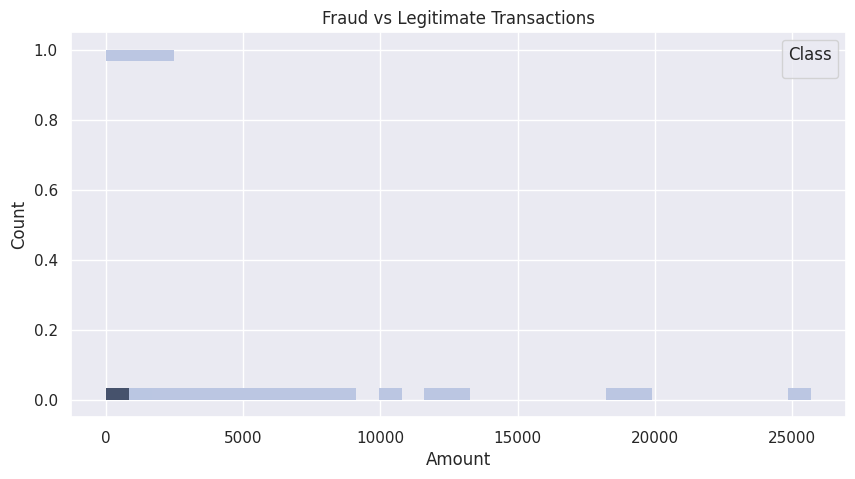

In [21]:
##Distribution
plt.figure(figsize=(10,5))
sns.histplot(data=df,x='Amount',y='Class',bins=31,kde=True)
plt.title("Fraud vs Legitimate Transactions")
plt.xlabel('Amount')
plt.ylabel('Count')
plt.legend(title='Class', labels=['Fraud', 'Legitimate'])
plt.show()


Text(0, 0.5, 'V17 Feature Value')

<Figure size 1200x500 with 0 Axes>

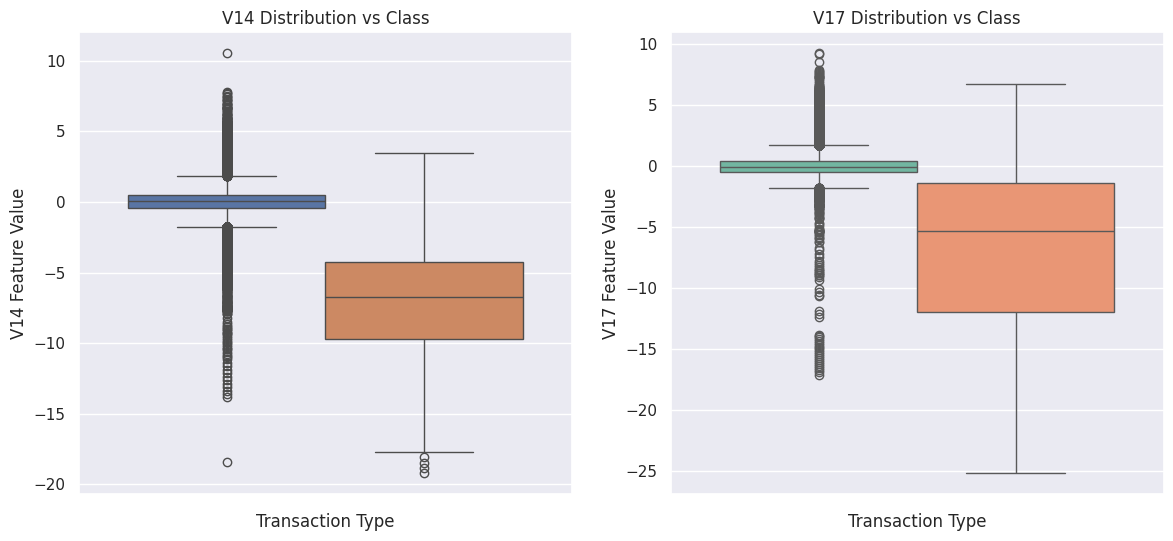

In [ ]:
## Boxplots
plt.figure(figsize=(12,5))
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(ax=axes[0],hue='Class',y='V14',data=df,legend=False)
sns.boxplot(ax=axes[1],hue='Class',y='V17',data=df,palette='Set2',legend=False)
axes[0].set_title('V14 Distribution vs Class')
axes[1].set_title('V17 Distribution vs Class')

axes[0].set_xlabel('Transaction Type')
axes[0].set_ylabel('V14 Feature Value')

axes[1].set_xlabel('Transaction Type')
axes[1].set_ylabel('V17 Feature Value')




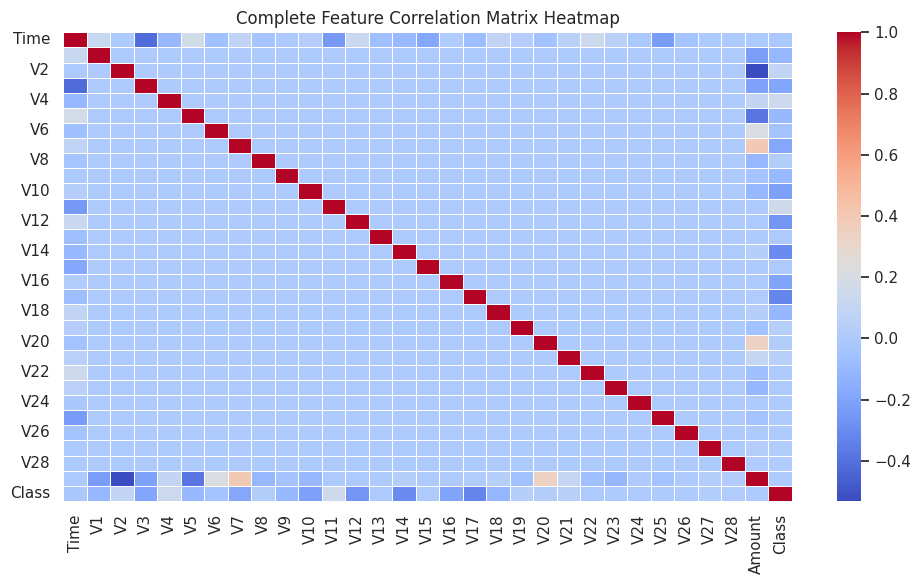

In [44]:
## HeatMaps

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm',  annot=False, fmt=".2f", linewidths=0.5)
plt.title('Complete Feature Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()